In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("bank_churn.csv")

df.head()

,ID,balance,credit_card,credit_score,estimated_salary,gender,products_number,churn
0,0,170474.195746,0,677,56050.569684,1,1,1
1,1,179904.000000,1,735,137180.950000,1,1,0
2,2,81732.880000,1,736,136497.280000,0,2,0
3,3,73211.120000,1,545,89587.340000,1,2,1
4,4,0.000000,1,624,108841.830000,1,2,0


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (600, 8)

Columns:
Index(['ID', 'balance', 'credit_card', 'credit_score', 'estimated_salary',
       'gender', 'products_number', 'churn'],
      dtype='object')

Data Types:
ID                    int64
balance             float64
credit_card           int64
credit_score          int64
estimated_salary    float64
gender                int64
products_number       int64
churn                 int64
dtype: object

Missing Values:
ID                  0
balance             0
credit_card         0
credit_score        0
estimated_salary    0
gender              0
products_number     0
churn               0
dtype: int64


churn
1    300
0    300
Name: count, dtype: int64


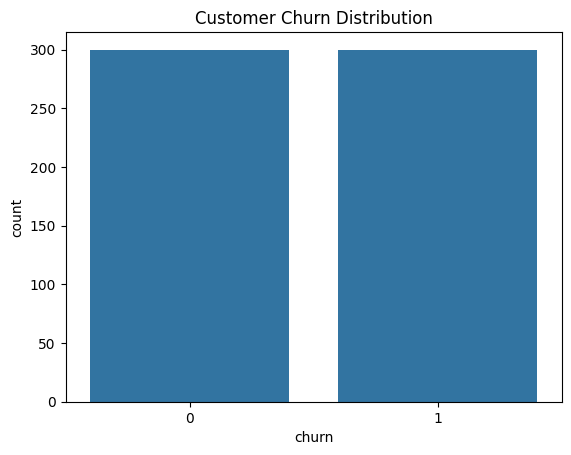

In [4]:
print(df["churn"].value_counts())

sns.countplot(x="churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()


In [5]:
X = df.drop(columns=["churn", "ID"])
y = df["churn"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['balance', 'credit_card', 'credit_score', 'estimated_salary', 'gender',
       'products_number'],
      dtype='object')

Target:
churn


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480, 6)
Testing data: (120, 6)


In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 1]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.6916666666666667
Accuracy percentage: 69.16666666666667 %


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[44 16]
 [21 39]]


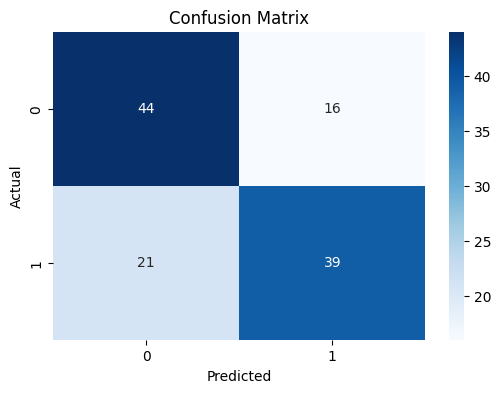

In [11]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
2,credit_score,0.000046
0,balance,0.000004
3,estimated_salary,0.000003
1,credit_card,-0.444841
5,products_number,-0.647652
4,gender,-1.573810


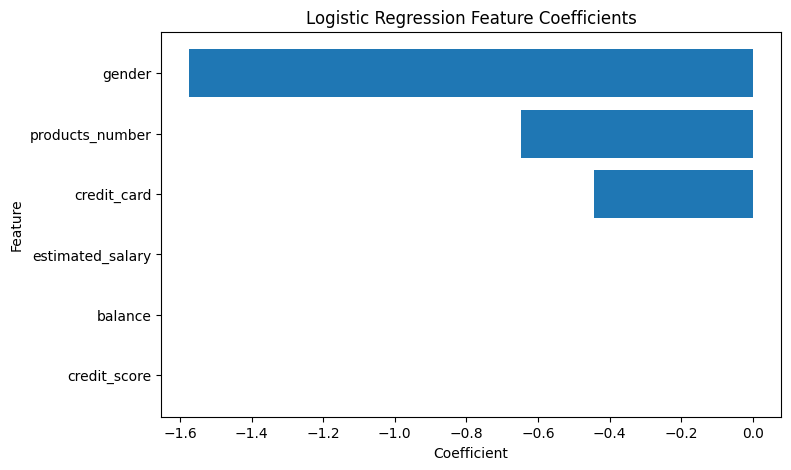

In [13]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")

plt.show()
